In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"parralex","key":"0c383bd852eb531b27efea09f239a555"}'}

**After API upload**

In [2]:
import os

# create kaggle folder
os.makedirs('/root/.kaggle', exist_ok=True)

# move file
!mv kaggle.json /root/.kaggle/

# set permissions
!chmod 600 /root/.kaggle/kaggle.json

In [3]:
!pip install kaggle

In [4]:
!kaggle datasets download -d kandij/electric-production

Dataset URL: https://www.kaggle.com/datasets/kandij/electric-production
License(s): unknown
100% 2.63k/2.63k [00:00<00:00, 10.2MB/s]



In [5]:
import zipfile

with zipfile.ZipFile('electric-production.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/data')

**Dataset Reading**

In [6]:
import pandas as pd

df = pd.read_csv('/content/data/Electric_Production.csv')

df.head()

,DATE,Value
0,01-01-1985,72.5052
1,02-01-1985,70.6720
2,03-01-1985,62.4502
3,04-01-1985,57.4714
4,05-01-1985,55.3151


**Preprocessing**

In [15]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

Count=50

df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')

data = df[['Value']].values

# normalizing not as necessary but we will do it
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

def create_dataset(data, time_step=30):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 30
X, y = create_dataset(data_scaled, time_step)

X = X.reshape(X.shape[0], X.shape[1], 1)

# 80 percent Training ke liye
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

**RNN**

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(time_step,1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.fit(X_train, y_train, epochs=Count, batch_size=32, validation_data=(X_test,y_test))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - loss: 0.0106 - val_loss: 0.0076
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0038 - val_loss: 0.0054
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0026 - val_loss: 0.0048
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0040 - val_loss: 0.0045
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0026 - val_loss: 0.0034
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0023 - val_loss: 0.0036
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0021 - val_loss: 0.0033
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0018 - val_loss: 0.0029
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0019 - val_loss: 0.0029
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0017 - val_loss: 0.0029
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0017 - val_loss: 0.0029
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0015 - val_

**LSTM**

In [17]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(time_step,1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=Count, batch_size=32, validation_data=(X_test,y_test))

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.1385 - val_loss: 0.0215
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0192 - val_loss: 0.0174
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0155 - val_loss: 0.0271
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0137 - val_loss: 0.0164
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0128 - val_loss: 0.0176
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0125 - val_loss: 0.0171
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0125 - val_loss: 0.0166
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0120 - val_loss: 0.0173
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0118 - val_loss: 0.0164
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0116 - val_loss: 0.0168
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0115 - val_loss: 0.0164
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0

**GRU**

In [18]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    GRU(64, input_shape=(time_step,1)),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train, y_train, epochs=Count, batch_size=32, validation_data=(X_test,y_test))

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.1338 - val_loss: 0.0590
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0240 - val_loss: 0.0229
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0219 - val_loss: 0.0246
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0172 - val_loss: 0.0343
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0173 - val_loss: 0.0233
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0156 - val_loss: 0.0192
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0151 - val_loss: 0.0205
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0144 - val_loss: 0.0189
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0139 - val_loss: 0.0201
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0133 - val_loss: 0.0174
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0128 - val_loss: 0.0185
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

**Vision Transformer**

In [19]:
import tensorflow as tf
from tensorflow.keras.layers import LayerNormalization, MultiHeadAttention, Dense, Dropout, Flatten

def transformer_model():
    inputs = tf.keras.Input(shape=(time_step,1))

    x = LayerNormalization()(inputs)
    x = MultiHeadAttention(num_heads=2, key_dim=32)(x, x)
    x = Dropout(0.1)(x)

    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')

    return model

vit_model = transformer_model()
vit_model.fit(X_train, y_train, epochs=Count, batch_size=32, validation_data=(X_test,y_test))

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 323ms/step - loss: 0.2227 - val_loss: 0.4041
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2142 - val_loss: 0.3919
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2058 - val_loss: 0.3799
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1978 - val_loss: 0.3681
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1898 - val_loss: 0.3567
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1823 - val_loss: 0.3456
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1750 - val_loss: 0.3348
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1680 - val_loss: 0.3242
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1611 - val_loss: 0.3138
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1546 - val_loss: 0.3040
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1483 - val_loss: 0.2945
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1423 - va

**Forecasting**

In [23]:
def forecast(model, data, scaler, time_step=30, steps=3650):
    temp_input = list(data[-time_step:].flatten())
    output = []

    for i in range(steps):
        x_input = np.array(temp_input[-time_step:])
        x_input = x_input.reshape(1, time_step, 1)

        yhat = model.predict(x_input, verbose=0)

        # extract scalar safely
        yhat_value = float(yhat[0][0])

        temp_input.append(yhat_value)
        output.append(yhat_value)

    output = np.array(output).reshape(-1,1)

    return scaler.inverse_transform(output)

forecast_values = forecast(
    model=lstm_model,
    data=data_scaled,
    scaler=scaler,
    time_step=30,
    steps=120
)

**Graphs dekhlo**

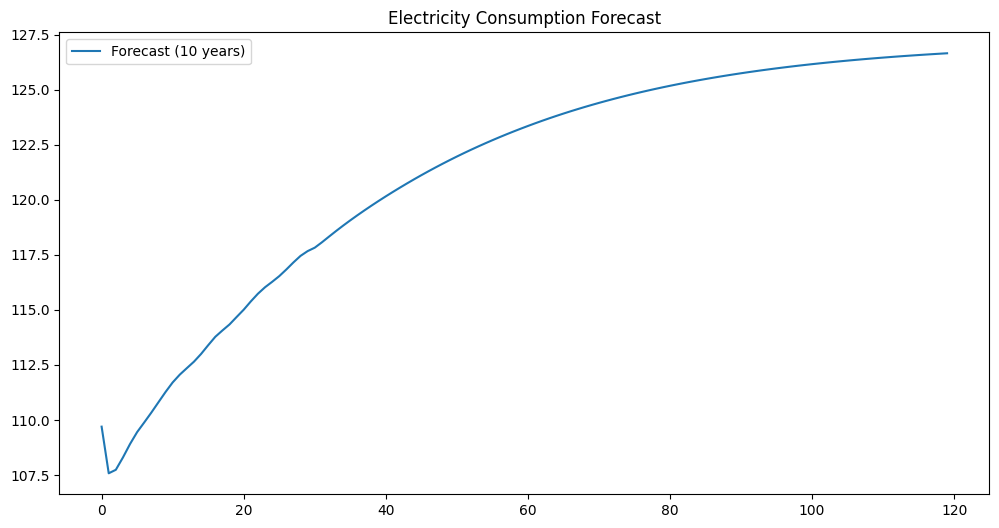

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(forecast_values, label='Forecast (10 years)')
plt.legend()
plt.title("Electricity Consumption Forecast")
plt.show()

**Results Dekhlo**

In [25]:
from sklearn.metrics import mean_squared_error

def evaluate(model):
    pred = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, pred))

print("RNN RMSE:", evaluate(rnn_model))
print("LSTM RMSE:", evaluate(lstm_model))
print("GRU RMSE:", evaluate(gru_model))
print("ViT RMSE:", evaluate(vit_model))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step
RNN RMSE: 0.05419605036401742
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 
LSTM RMSE: 0.13505215480070265


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
GRU RMSE: 0.06379555007003923
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step
ViT RMSE: 0.30884873651028355
